<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P6/Tugas_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas 1

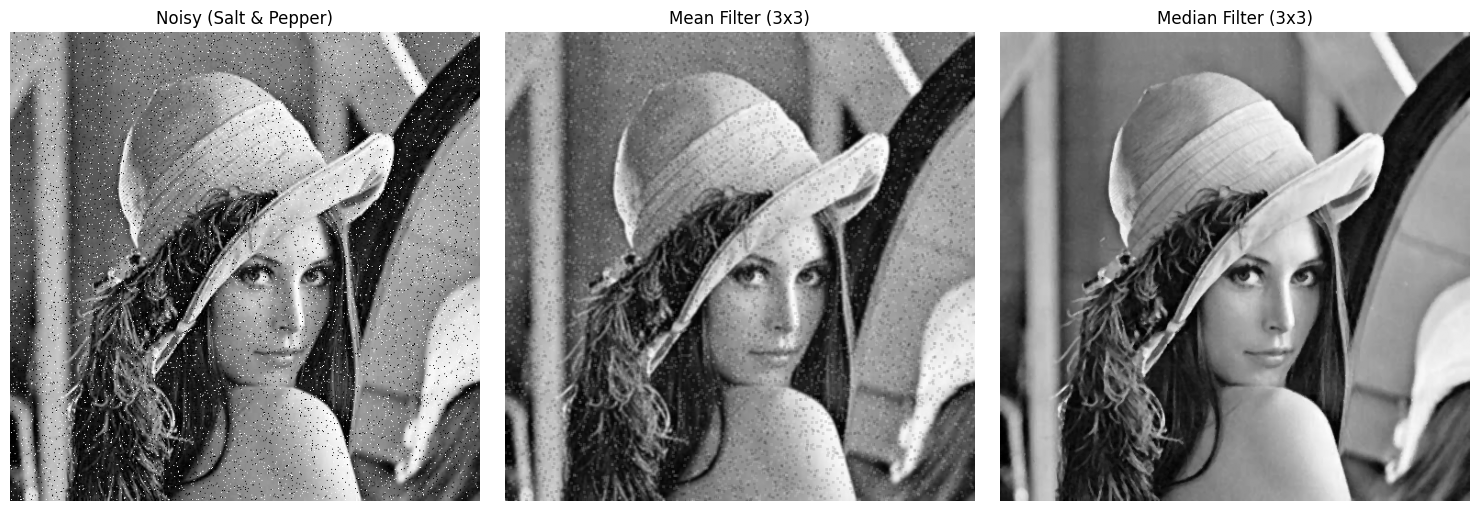

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# A.noise Salt & Pepper
def add_salt_and_pepper_noise(image, amount=0.04):
    noisy_img = image.copy()
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_img[tuple(coords)] = 255

    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_img[tuple(coords)] = 0
    return noisy_img

def show_side_by_side(images, titles):
    n = len(images)
    plt.figure(figsize=(5 * n, 5))
    for i in range(n):
      plt.subplot(1, n, i + 1)
      plt.imshow(images[i], cmap='gray')
      plt.title(titles[i])
      plt.axis('off')
    plt.tight_layout()
    plt.show()

img_gray_lena = cv.imread('/content/drive/MyDrive/PCVK_2026/lena.jpg', cv.IMREAD_GRAYSCALE)

img_noisy = add_salt_and_pepper_noise(img_gray_lena, amount=0.05)

# B.Mean Filter (3x3) & Median Filter (3x3)
mean_kernel = np.ones((3,3), np.float32) / 9.0
img_mean_filtered = cv.filter2D(img_noisy, -1, mean_kernel)
img_median_filtered = cv.medianBlur(img_noisy, 3)

show_side_by_side([img_noisy, img_mean_filtered, img_median_filtered],
                   ["Noisy (Salt & Pepper)", "Mean Filter (3x3)", "Median Filter (3x3)"])

Tugas 2

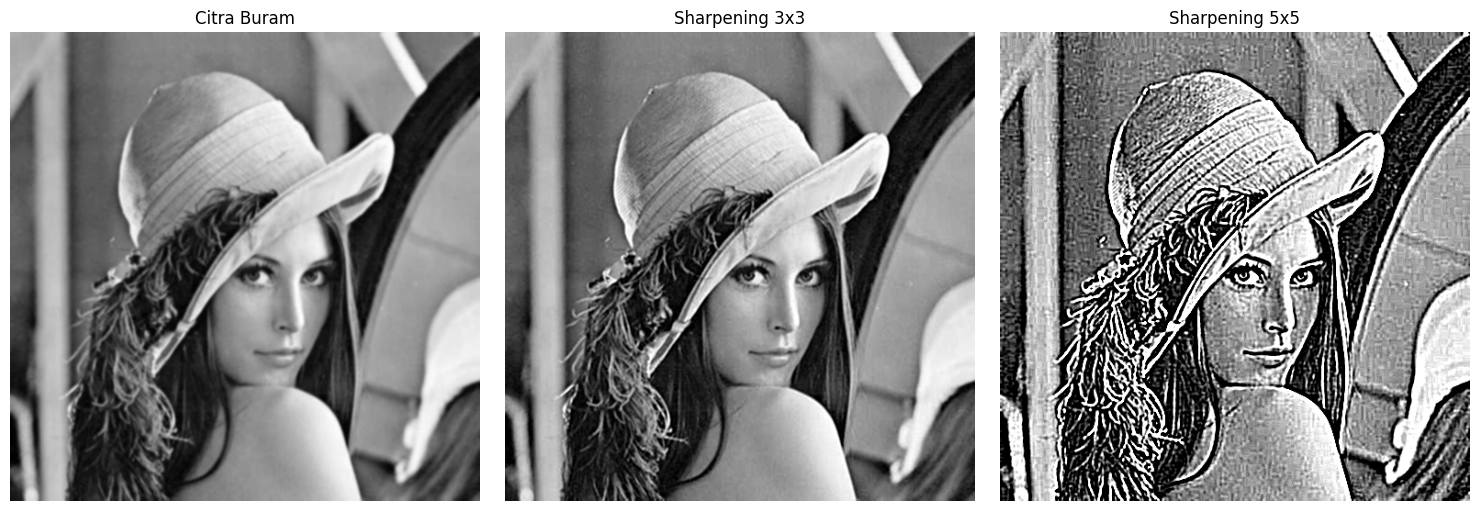

In [9]:
kernel_sharp_3x3 = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])

kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, 25, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1]])

img_blurry = cv.GaussianBlur(img_gray_lena, (5, 5), 0)
sharp_3x3 = cv.filter2D(img_blurry, -1, kernel_sharp_3x3)
sharp_5x5 = cv.filter2D(img_blurry, -1, kernel_sharp_5x5)

show_side_by_side([img_blurry, sharp_3x3, sharp_5x5],
                   ["Citra Buram", "Sharpening 3x3", "Sharpening 5x5"])

Tugas 3

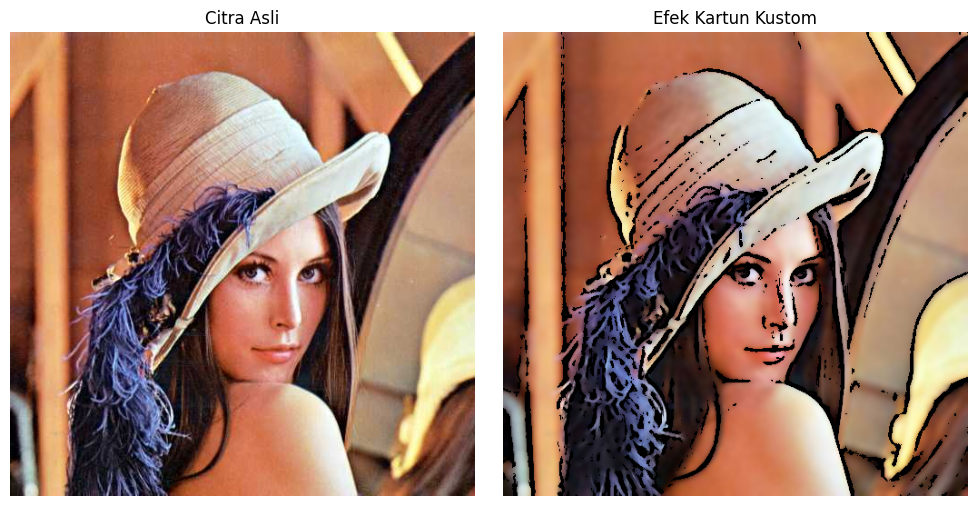

In [12]:
def kartun(image):

    # 1.Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=150, sigmaSpace=150)

    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 5)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY,
                                 blockSize=9, C=8)

    # mask edges ke 3 kanal warna BGR
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    cartoon_img = cv.bitwise_and(color, edges_bgr)
    return cartoon_img

img_lena = cv.imread('/content/drive/MyDrive/PCVK_2026/lena.jpg')

img_lena_rgb = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

img_kartun = kartun(img_lena)
img_kartun_rgb = cv.cvtColor(img_kartun, cv.COLOR_BGR2RGB)

show_side_by_side([img_lena_rgb, img_kartun_rgb], ["Citra Asli", "Efek Kartun Kustom"])